In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [7]:
# Load the dataset
planes_data = pd.read_csv('plane.csv', encoding='latin-1')
print(planes_data.head())

# --- 1. Fix date format ---
planes_data['Date'] = pd.to_datetime(planes_data['Date'], errors='coerce')
planes_data['Year'] = planes_data['Date'].dt.year
planes_data['Decade'] = (planes_data['Year'] // 10 * 10).astype('Int64')

# --- 2. Replace 'NULL' strings with actual NaN ---
planes_data.replace('NULL', np.nan, inplace=True)

# --- 3. Cast numeric columns ---
numeric_cols = ['Aboard', 'Aboard Passangers', 'Aboard Crew',
                'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground']
planes_data[numeric_cols] = planes_data[numeric_cols].apply(pd.to_numeric, errors='coerce')

# --- 4. Engineer: Survival count and survival rate ---
planes_data['Survived'] = planes_data['Aboard'] - planes_data['Fatalities']
planes_data['Survival Rate'] = planes_data['Survived'] / planes_data['Aboard']

# --- 5. Extract Country from Location ---
planes_data['Country'] = planes_data['Location'].dropna().apply(
    lambda x: x.split(',')[-1].strip()
)

# --- 6. Categorize Operator ---
def categorize_operator(op):
    if pd.isna(op):
        return 'Unknown'
    op_lower = op.lower()
    if 'military' in op_lower:
        return 'Military'
    elif 'private' in op_lower:
        return 'Private'
    else:
        return 'Commercial'

planes_data['Operator Category'] = planes_data['Operator'].apply(categorize_operator)

# --- Confirm results ---
print(planes_data[['Date', 'Year', 'Decade', 'Survived', 'Survival Rate', 
                    'Country', 'Operator Category']].head())
print("\nMissing values:\n", planes_data.isnull().sum())

        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1          SC1   NaN     1.0  

In [8]:
# Rows with no fatality AND no aboard data are useless for every analysis
planes_data.dropna(subset=['Fatalities', 'Aboard'], how='all', inplace=True)
print(f"Remaining rows: {len(planes_data)}")
# When analyzing survival rate
survival_df = planes_data.dropna(subset=['Survival Rate'])

# When analyzing by region
region_df = planes_data.dropna(subset=['Country'])

# When analyzing by operator type
operator_df = planes_data.dropna(subset=['Operator Category'])  # already 0 missing

Remaining rows: 4990


## 📋 Step 1 – Data Import & Cleaning

- Loaded with `encoding='latin-1'` to handle special characters in international location names
- Replaced `'NULL'` strings → `NaN`, cast numeric columns to `float`
- Converted `Date` → `datetime`, extracted `Year` and `Decade`
- Engineered `Survived` and `Survival Rate` columns
- Extracted `Country` from `Location`, categorized `Operator` into `Military / Commercial / Private / Unknown`
- Dropped rows missing **both** `Fatalities` and `Aboard` — useless for any analysis
- Remaining missing values handled **locally per step** using `.dropna(subset=[...])`

                                Date       Aboard  Aboard Passangers  \
count                           4990  4980.000000        4769.000000   
mean   1971-07-22 18:42:51.222444904    31.195984          27.009017   
min              1908-09-17 00:00:00     0.000000           0.000000   
25%              1951-07-12 00:00:00     7.000000           3.000000   
50%              1970-12-06 00:00:00    16.000000          12.000000   
75%              1992-06-22 00:00:00    35.000000          30.000000   
max              2023-11-01 00:00:00   644.000000         614.000000   
std                              NaN    45.534788          44.111609   

       Aboard Crew   Fatalities  Fatalities Passangers  Fatalities Crew  \
count  4772.000000  4990.000000            4756.000000      4757.000000   
mean      4.479254    22.373547              19.053827         3.578516   
min       0.000000     0.000000               0.000000         0.000000   
25%       2.000000     4.000000               1.000

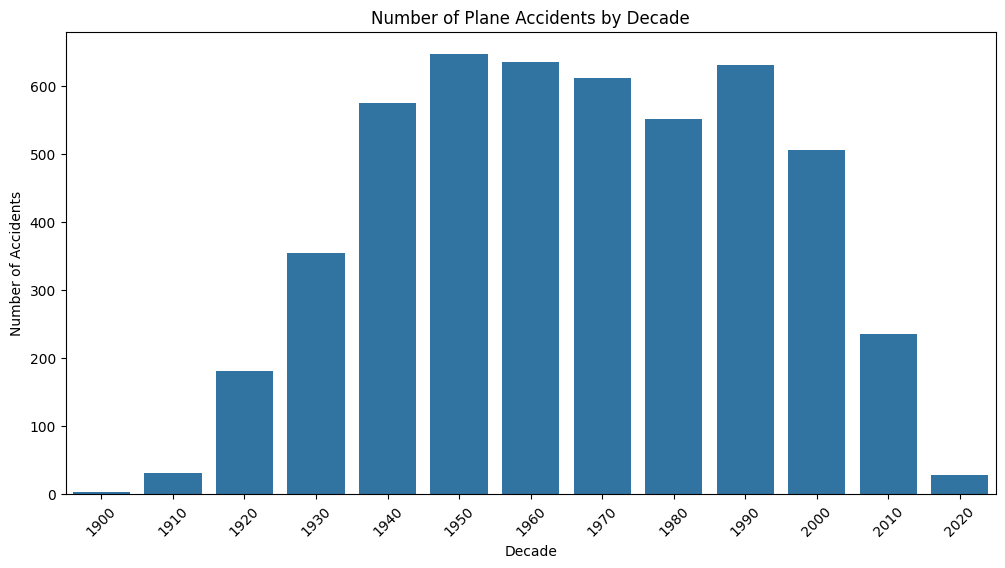

In [10]:
#2: Basic EDA
print(planes_data.describe())
print("Total Recorded Accidents:", len(planes_data))
print("Total Fatalities:", planes_data['Fatalities'].sum())
print("Average Survival Rate:", planes_data['Survival Rate'].mean())

#Graph of accidents over time
plt.figure(figsize=(12, 6))
sns.countplot(x='Decade', data=planes_data, order=sorted(planes_data['Decade'].dropna().unique()))
plt.title('Number of Plane Accidents by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

## 📋 Step 2 – Exploratory Data Analysis

- **4,990** total recorded accidents across **1908–2023**
- **111,644** total fatalities with an average of **~22 per crash**
- **Average survival rate: 18%** — the majority of crashes are fatal for most or all aboard
- Median survival rate is **0%**, meaning in over half of all crashes, there were no survivors
- Accidents peak in the **1970s–1990s** — reflecting the boom in commercial aviation
- Post-2000 decline likely reflects improved safety regulations, technology, and aircraft design

In [12]:
#3: Statistical Analysis

# Distribution of Fatalities
fatalities_desc = planes_data['Fatalities'].describe()
print("Average Fatalities Per Accident:", fatalities_desc['mean'])
print("Median Fatalities:", fatalities_desc['50%'])
print("Standard Deviation of Fatalities:", fatalities_desc['std'])

# Distribution of Survival Rates
survival_desc = planes_data['Survival Rate'].describe()
print("Average Survival Rate:", survival_desc['mean'])
print("Median Survival Rate:", survival_desc['50%'])
print("Standard Deviation of Survival Rate:", survival_desc['std'])

Average Fatalities: 22.37354709418838
Median Fatalities: 11.0
Standard Deviation of Fatalities: 35.06174065974316
Average Survival Rate: 0.181489019431307
Median Survival Rate: 0.0
Standard Deviation of Survival Rate: 0.3117242492487905


In [16]:
print(planes_data.info())
print(planes_data['Operator Category'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 4990 entries, 0 to 4997
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4990 non-null   datetime64[ns]
 1   Time                   3486 non-null   object        
 2   Location               4986 non-null   object        
 3   Operator               4980 non-null   object        
 4   Flight #               1329 non-null   object        
 5   Route                  4220 non-null   object        
 6   AC Type                4977 non-null   object        
 7   Registration           4719 non-null   object        
 8   cn/ln                  4330 non-null   object        
 9   Aboard                 4980 non-null   float64       
 10  Aboard Passangers      4769 non-null   float64       
 11  Aboard Crew            4772 non-null   float64       
 12  Fatalities             4990 non-null   float64       
 13  Fataliti

In [18]:
print("Hypothesis Test: Comparing Average number of accidents for Military vs Commercial")
print("Null Hypothesis: There is no difference in average number of accidents between Military and Commercial operators.")
military_accidents = planes_data[planes_data['Operator Category'] == 'Military']['Fatalities'].dropna()
commercial_accidents = planes_data[planes_data['Operator Category'] == 'Commercial']['Fatalities'].dropna()

t_stat, p_value = stats.ttest_ind(military_accidents, commercial_accidents, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

alpha = 0.05
df=len(military_accidents) + len(commercial_accidents) - 2
print(f"Degrees of Freedom: {df}")

critical_value = stats.t.ppf(1 - alpha/2, df)
print(f"Critical Value for two-tailed test at alpha={alpha}: ±{critical_value}")
print(f"Calculated |T| = {abs(t_stat):.3f}")
print(f"Critical |T|   = {critical_value:.3f}")

if abs(t_stat) > critical_value:
    print("\nSince the calculated |T| is GREATER than the critical value:")
    print("Reject the null hypothesis. There is a statistically significant difference in average fatalities between Military and Commercial operators.")
else:
    print("\nSince the calculated |T| is LESS than or equal to the critical value:")
    print("Fail to reject the null hypothesis. There is no statistically significant difference in average fatalities between Military and Commercial operators.")

print("Testing using p-value:")
if p_value < alpha:
    print("Reject the null hypothesis. There is a statistically significant difference in average fatalities between Military and Commercial operators. The p-value is less than the significance level (alpha).")
else:
    print("Fail to reject the null hypothesis. There is no statistically significant difference in average fatalities between Military and Commercial operators. The p-value is not less than the significance level (alpha).")

Hypothesis Test: Comparing Average number of accidents for Military vs Commercial
Null Hypothesis: There is no difference in average number of accidents between Military and Commercial operators.
T-statistic: 4.318081029622826, P-value: 1.6846145091869232e-05
Degrees of Freedom: 4900
Critical Value for two-tailed test at alpha=0.05: ±1.9604482391026838
Calculated |T| = 4.318
Critical |T|   = 1.960

Since the calculated |T| is GREATER than the critical value:
Reject the null hypothesis. There is a statistically significant difference in average fatalities between Military and Commercial operators.
Testing using p-value:
Reject the null hypothesis. There is a statistically significant difference in average fatalities between Military and Commercial operators. The p-value is less than the significance level (alpha).


In [19]:
print("Average Fatalities - Military:", military_accidents.mean())
print("Average Fatalities - Commercial:", commercial_accidents.mean())
print("Conclusion: Military operators have a higher average number of fatalities per accident compared to Commercial operators, and this difference is statistically significant based on our t-test results.")

Average Fatalities - Military: 26.49800796812749
Average Fatalities - Commercial: 21.82887442757291


## 📋 Step 3 – Statistical Analysis

**Fatality Distribution:**
- Mean (**22.4**) is double the median (**11.0**) — indicates a right-skewed distribution driven by a small number of mass-casualty events
- High standard deviation (**35.1**) confirms wide variance — most crashes are small, but outliers are extreme

**Survival Rate Distribution:**
- Mean **18%**, median **0%** — in more than half of all crashes, nobody survived
- Confirms that surviving a plane crash is the exception, not the norm

**Hypothesis Test — Military vs. Commercial Fatalities:**
- H₀: No difference in average fatalities between Military and Commercial operators
- Result: **Rejected** — `|T| = 4.318 > critical value 1.960`, `p = 0.0000168`
- Military avg: **26.5** vs Commercial avg: **21.8** fatalities per crash
- The difference is small in absolute terms but **statistically significant** with ~4,900 degrees of freedom

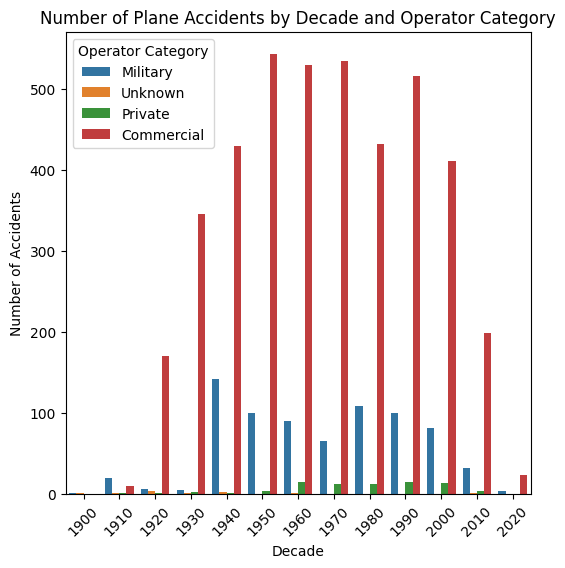

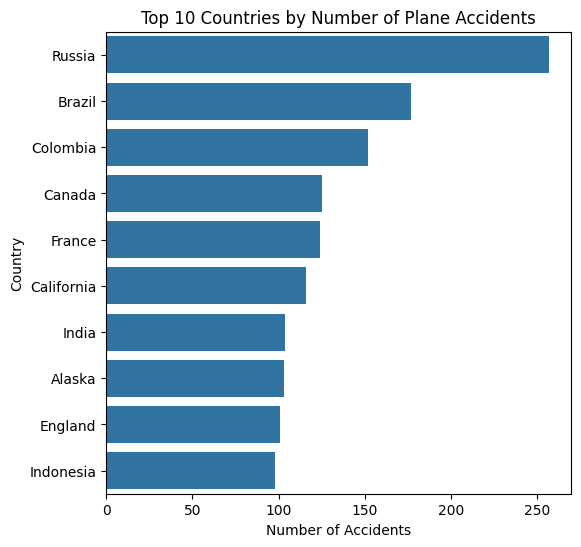

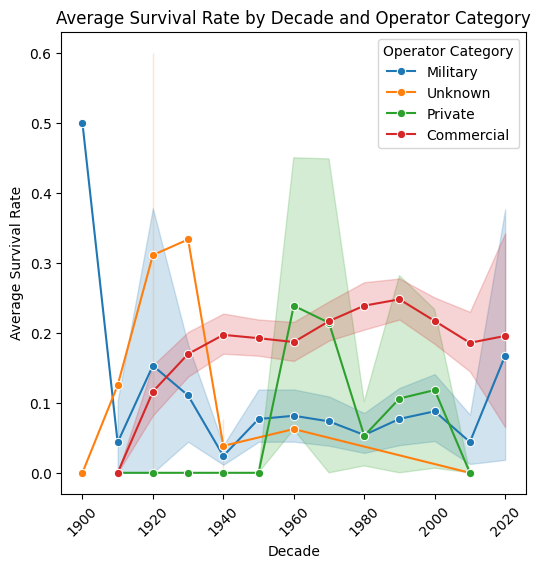

In [21]:
#4: Visualization
#Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
#Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.

#Accidents by Operator Category over time
plt.figure(figsize=(6, 6))
sns.countplot(x='Decade', hue='Operator Category', data=planes_data, order=sorted(planes_data['Decade'].dropna().unique()))
plt.title('Number of Plane Accidents by Decade and Operator Category')
plt.xlabel('Decade')
plt.ylabel('Number of Accidents')
plt.legend(title='Operator Category')
plt.xticks(rotation=45)
plt.show()

#Bar chart of total crashes by region
plt.figure(figsize=(6, 6))
region_counts = region_df['Country'].value_counts().head(10)  # Top 10 countries
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title('Top 10 Countries by Number of Plane Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Country')
plt.show()

#Graph of Survival Rate by Operator Category over time
plt.figure(figsize=(6, 6))
sns.lineplot(x='Decade', y='Survival Rate', hue='Operator Category', data=operator_df, marker='o')
plt.title('Average Survival Rate by Decade and Operator Category')
plt.xlabel('Decade')
plt.ylabel('Average Survival Rate')
plt.legend(title='Operator Category')
plt.xticks(rotation=45)
plt.show()




## 📋 Step 4 – Visualization: Survival Rate by Decade & Operator

- **Commercial** survival rate shows a clear upward trend from near 0% (early aviation) to ~25% by 2000s
  — reflects decades of safety regulation, better aircraft design, and improved emergency procedures
- **Military** survival rate hits its lowest point in the **1940s–1960s** — aligning with WWII and the
  Korean/Vietnam War eras where combat losses dominate the data
- Military rates have **slightly recovered post-2000**, likely reflecting peacetime operations and
  improved aircraft survivability
- **Unknown** category spikes in early decades (1900s–1930s) due to sparse, poorly documented records
  — less reliable for trend analysis
- **Private** aviation shows high volatility throughout — small sample sizes per decade make the trend
  unstable and harder to interpret
- The wide **confidence bands** in early decades reflect low data volume; bands narrow post-1950 as
  records become more complete

## 📋 Step 5 – Summary & Insights

**Key Findings:**

- Aviation has become significantly safer over time — commercial survival rates have risen steadily
  since the 1950s, coinciding with IATA formation, mandatory black boxes, and modern ATC systems
- Despite improved safety, **18% average survival rate** across all crashes highlights that
  plane crashes remain highly fatal events
- The **1970s–1990s** saw peak accident frequency — a direct result of rapid commercial aviation
  expansion outpacing safety infrastructure
- Military crashes are statistically **more fatal on average** (26.5 vs 21.8) — confirmed by our
  t-test (p < 0.0001) — driven by combat losses and high-risk operational conditions
- Fatality distribution is heavily **right-skewed** — most crashes involve under 25 fatalities,
  but rare mass-casualty events (500+) pull the mean significantly upward

**Anomalies & Limitations:**
- Early records (pre-1940) are sparse and inconsistently documented — survival rate trends
  in this period should be interpreted cautiously
- `Country` extraction from free-text `Location` is imperfect — locations like "Over the North Sea"
  skew regional analysis
- `Flight #` and `Route` missing in the majority of records — route-based analysis not feasible